In [1]:
import sys
# change the system path to the partent directory of the current file, so that we can import the QNN framework
sys.path.append("..")

In [2]:
import matplotlib.pyplot as plt
import pennylane as qp
from pennylane import numpy as np

import torch


from importlib import reload

In [65]:
import circuits
reload(circuits)
import functions
reload(functions)
import experiment_tracker
reload(experiment_tracker)

<module 'experiment_tracker' from '/home/tardant/Bureau/pennylane/Circuits_training/notebooks/../experiment_tracker.py'>

In [5]:

degree = 1  # degree of the target function
coeffs = [0.15 + 0.15j] * degree  # coefficients of non-zero frequencies
coeff0 = 0.1  # coefficient of zero frequency

def target_function(x):
    x_c = x.to(torch.complex64)
    """Generate a truncated Fourier series, where the data gets re-scaled."""
    res = torch.full_like(x_c, fill_value=coeff0, dtype=torch.complex64)
    for idx, coeff in enumerate(coeffs):
        k = idx + 1
        coeff_t = torch.as_tensor(coeff, dtype=torch.complex64, device=x.device)
        exponent = 1j * k * x_c
        res = res + coeff_t * torch.exp(exponent) + torch.conj(coeff_t) * torch.exp(-exponent)

    return torch.real(res)


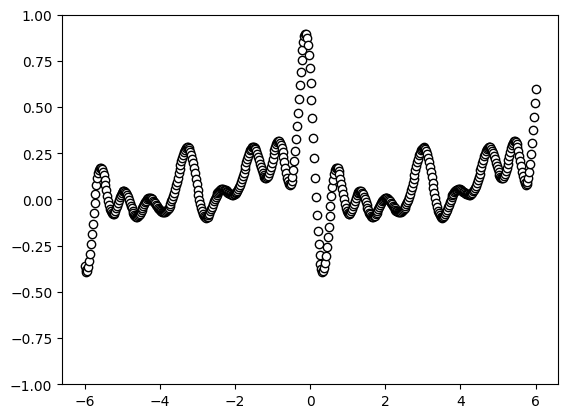

In [29]:
degree = 10  # degree of the target function
scaling = 1  # scaling of the data
coeffs = np.random.random(size=degree) + 1j * np.random.random(size=degree)  # coefficients of non-zero frequencies
# nomralize the coefficients so that the sum of the absolute values of the coefficients is 1
coeff0 = 0.1  # coefficient of zero frequency
coeffs = coeffs / np.sum(np.abs(coeffs))
coeffs = coeffs * (1 - coeff0) / 2  # scale the coefficients so that the sum of the absolute values of the coefficients is 1


dataset_size = 500
x = torch.linspace(-6, 6, dataset_size, requires_grad=False)
target_y = target_function(x)

plt.scatter(x, target_y, facecolor="white", edgecolor="black")
plt.ylim(-1, 1)
plt.show()

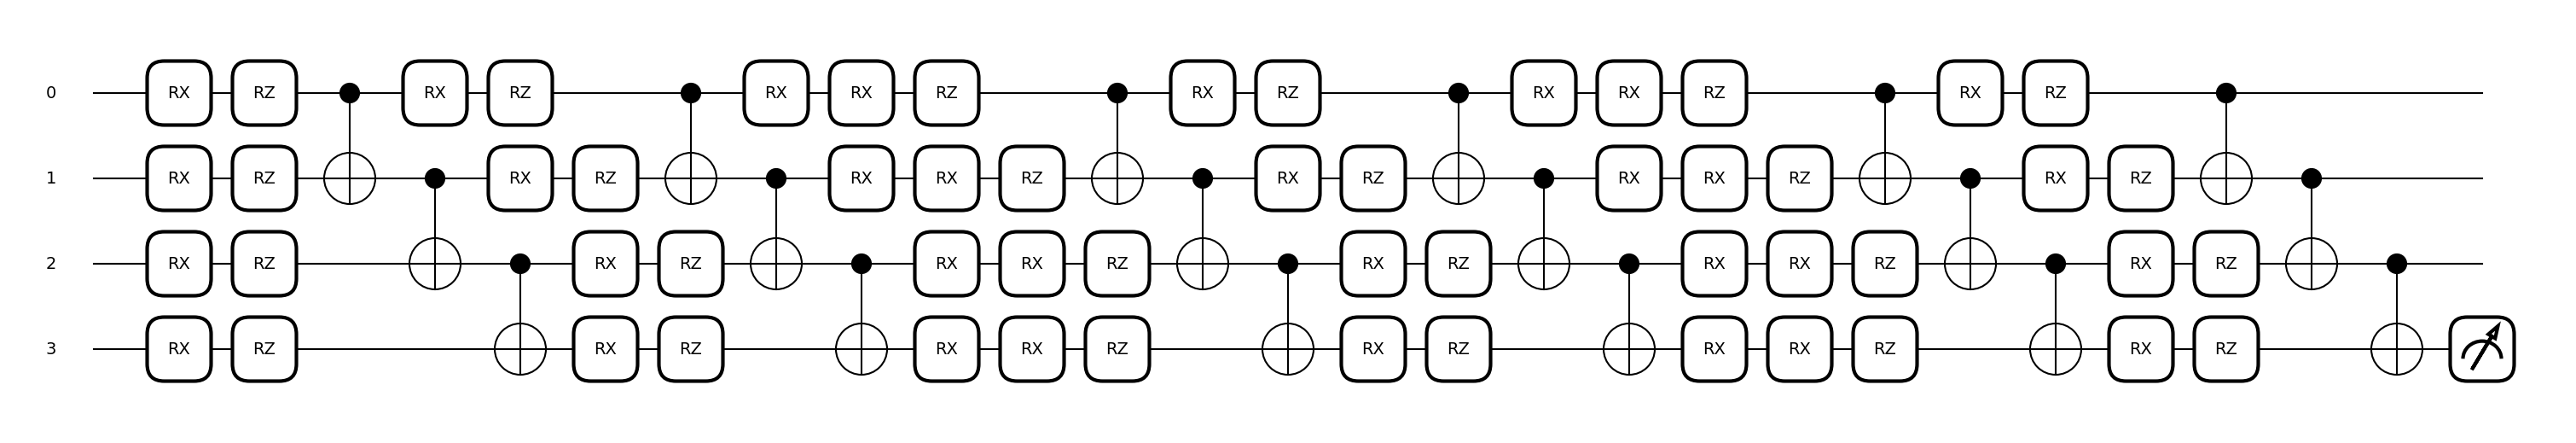

In [42]:
n_qubits = 4
layers = 3

num = 2  # circuit number to use

circuit, weights = functions.build_model(num, n_qubits, layers, anzats_reps=2, measuring_qubit=3)

qp.draw_mpl(circuit, level="device")(weights,0)
plt.show()

Cost at step  20: 0.00909324711797216
Cost at step  40: 0.007398473033858902
Cost at step  60: 0.002571577885797433
Cost at step  80: 0.0015444152759448927
Cost at step 100: 0.0017033200858066302
Cost at step 120: 0.0012882799659664015
Cost at step 140: 0.000878867714860492
Cost at step 160: 0.0011515571562045628
Cost at step 180: 0.0007937503187263434
Cost at step 200: 0.0007615512874385398


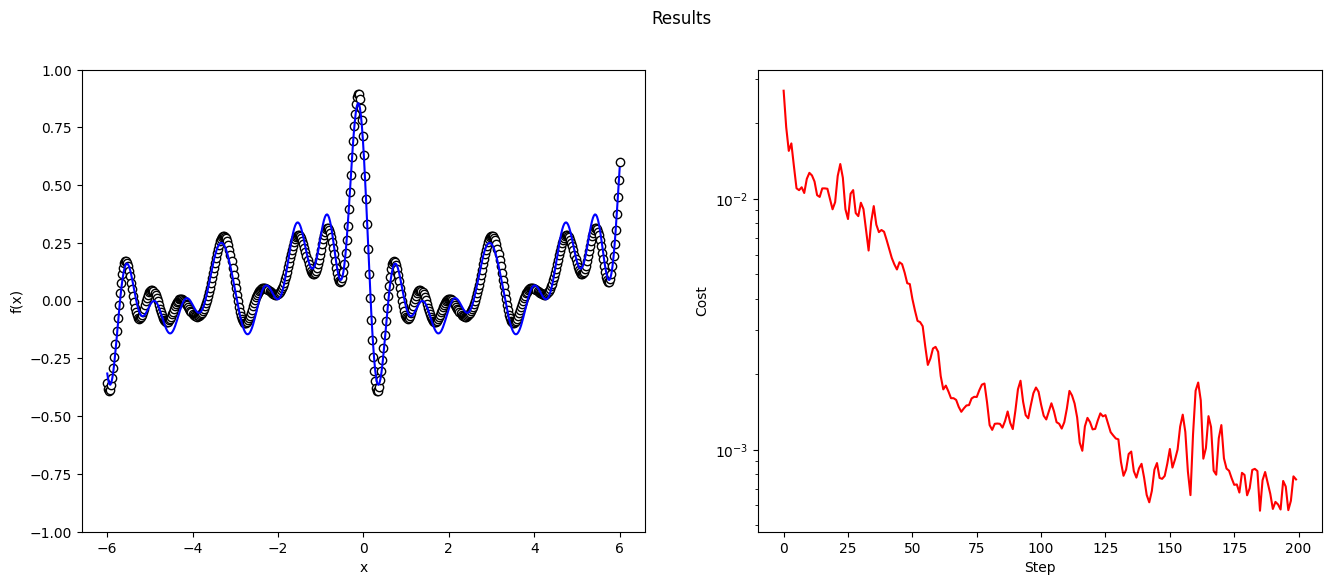

In [43]:
trained_weights, cst = functions.train(circuit, weights, x, target_y, max_steps=200, display_step=20)

functions.show_results(circuit,trained_weights, x, target_y, cst)

In [59]:
path = "../results/"

experiment_id, final_weights, cost_history = experiment_tracker.train_and_record(x, target_y, circuit_num=num, n_qubits=n_qubits, layers=layers, anzats_reps=2, path=path)

[tracker] Experiment cdd2739d-4b7d-42ed-82a0-277e5dac1d13 saved (circuit=2, qubits=4, layers=3, final_cost=0.007629)
